# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [72]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [73]:
# Inspect the shapes of the datasets
print(f'Shape of X_train is: {X_train.shape}')
print(f'Shape of y_train is: {y_train.shape}')
print(f'Shape of X_test is: {X_test.shape}')
print(f'Shape of y_test is: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_cat=to_categorical(y_train, num_classes=10)
y_test_cat=to_categorical(y_test, num_classes=10)



Shape of X_train is: (60000, 28, 28)
Shape of y_train is: (60000,)
Shape of X_test is: (10000, 28, 28)
Shape of y_test is: (10000,)


In [74]:
import pandas as pd
pd.DataFrame(y_train_cat).head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


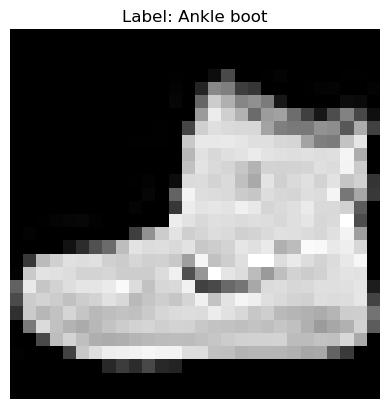

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Verify the data looks as expected
plt.imshow(X_train[0].reshape(28,28),cmap='gray')
plt.title(f'Label: {class_names[y_train[0]]}')
plt.axis('off')
plt.show()

In [76]:
X_train[0].reshape(28,28)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [77]:
print("X_train min:", X_train.min())
print("X_train max:", X_train.max())
print("X_test min:", X_test.min())
print("X_test max:", X_test.max())


X_train min: 0.0
X_train max: 1.0
X_test min: 0.0
X_test max: 1.0


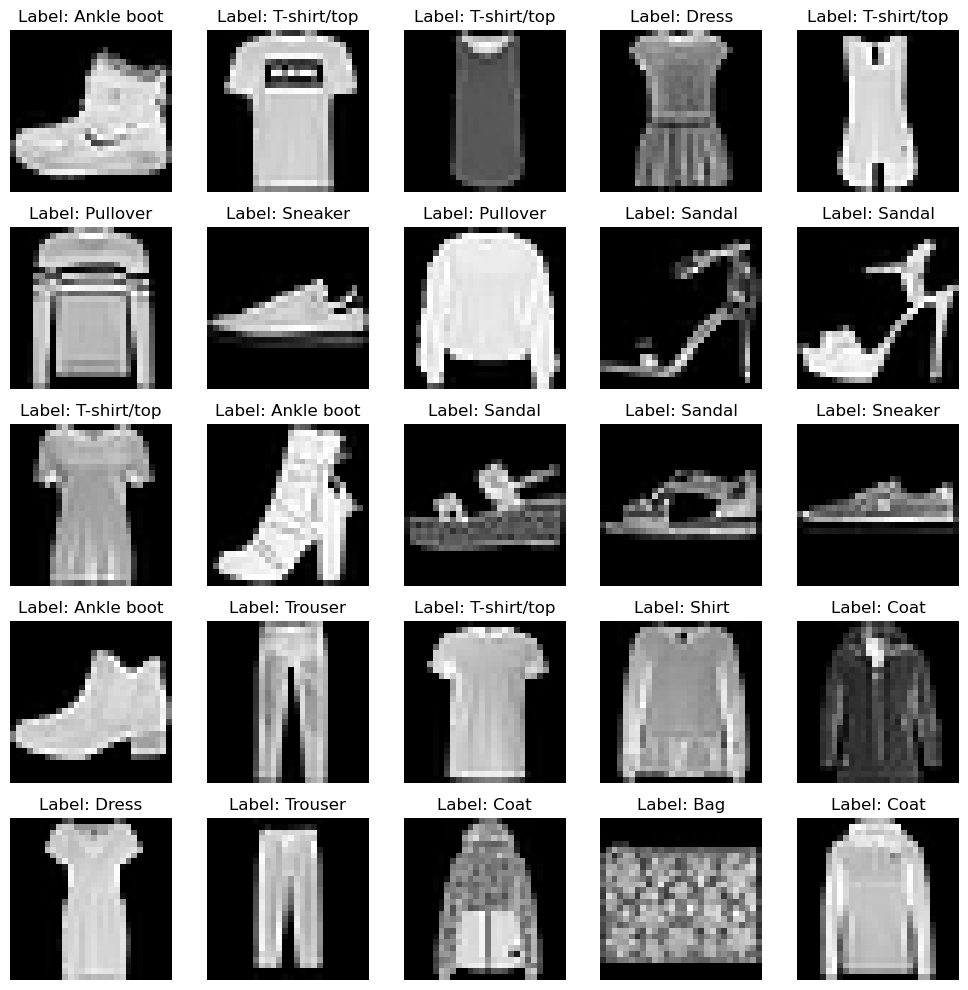

In [78]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


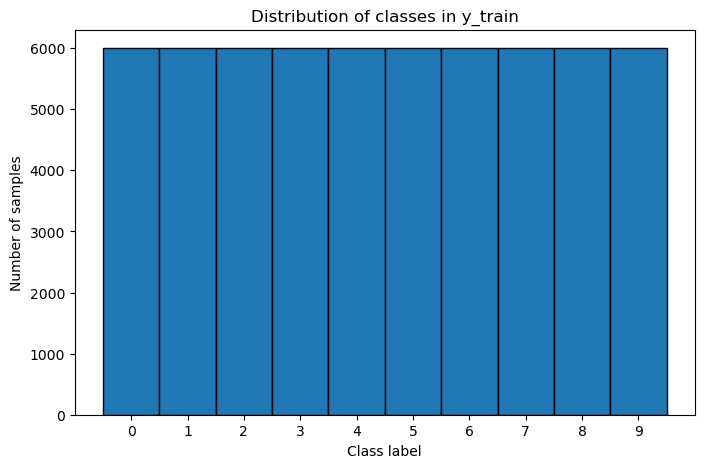

In [79]:
plt.figure(figsize=(8,5))
plt.hist(y_train, bins=np.arange(11)-0.5, edgecolor='black') 
plt.xticks(range(10)) 
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Distribution of classes in y_train")
plt.show()

In [80]:
import numpy as np

print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in X_test:", np.isnan(X_test).sum())


Missing values in X_train: 0
Missing values in X_test: 0


In [81]:
print("Missing values in y_train:", np.isnan(y_train).sum())
print("Missing values in y_test:", np.isnan(y_test).sum())


Missing values in y_train: 0
Missing values in y_test: 0


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

 - **The data looks as expected. The images are 28 X 28 grayscale, with correct labels matching the image. Also the normalization worked perfectly.**
 - **The images are of good resolution, sufficient for the classification task.**
 - **There are no major class difference. One needs to handle extra channel dimension (28,28,1) when feeding a CNN. One hot encoding has been applied on the label, so everything looks good.**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten


# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model

model.add(Input(shape=(28,28,1)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()
# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Train the model with `model.fit()`

model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate the model with `model.evaluate()`

loss, accuracy=model.evaluate(X_test, y_test_cat)

print(f'Loss: {loss:.2f}')
print(f'Accuracy: {accuracy: .2f}')

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5745 - loss: 1.3726 - val_accuracy: 0.7626 - val_loss: 0.6866
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7801 - loss: 0.6489 - val_accuracy: 0.8049 - val_loss: 0.5672
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8136 - loss: 0.5445 - val_accuracy: 0.8186 - val_loss: 0.5128
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8242 - loss: 0.5079 - val_accuracy: 0.8210 - val_loss: 0.4953
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8346 - loss: 0.4781 - val_accuracy: 0.8278 - val_loss: 0.4928
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8230 - loss: 0.5033
Loss: 0.52
Accuracy:  0.82


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?


**The training accuracy is about 83%, while the validation accuracy is around 82%. This is reasonable for a simple neural network with only Dense layers and no convolutional layers. The model captures basic patterns in the images but cannot learn more complex local spatial features due to the absence of convolutional operations.**

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(32,(3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()
# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Train the model

model.fit(
    X_train,
    y_train_cat,
    epochs=8,
    batch_size=64,
    validation_split=0.2
)

# Evaluate the model

loss, accuracy=model.evaluate(X_test, y_test_cat)

print(f'Loss: {loss:.2f}')
print(f'Accuracy: {accuracy: .2f}')

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351,306 (1.34 MB)

 Trainable params: 351,306 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7675 - loss: 0.6599 - val_accuracy: 0.8841 - val_loss: 0.3348
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8850 - loss: 0.3215 - val_accuracy: 0.8883 - val_loss: 0.3035
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9037 - loss: 0.2697 - val_accuracy: 0.9043 - val_loss: 0.2674
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9156 - loss: 0.2350 - val_accuracy: 0.9046 - val_loss: 0.2677
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9286 - loss: 0.2011 - val_accuracy: 0.9114 - val_loss: 0.2489
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9334 - loss: 0.1810 - val_accuracy: 0.9134 - val_loss: 0.2484
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9403 - loss: 0.1597 - val_accuracy: 0.9130 - val_loss: 0.2457
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9472 - loss: 0.1431 - val_accuracy: 0.9136 - v

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Yes, the CNN model performed better than the baseline. The accuracy improved from 0.82 to 0.91, an increase of approximately 0.09. This improvement is because the CNN includes an additional convolutional layer, which preserves the spatial and local characteristics of the image data, allowing the model to learn features more effectively. I also used the Adam optimizer with a learning rate of 0.001 and trained for 8 epochs instead of 5, which helped achieve better performance compared to using SGD.**

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [116]:
from keras.layers import Dropout
from keras.regularizers import l2 as l2_regularizer

def create_cnn_model(number_conv_layer=1, filter=32, kernel_size=(3,3), use_dropout=False, l2_reg=0.0, neuron=64):
    model=Sequential()
    model.add(Input(shape=(28,28,1)))
    for _ in range(number_conv_layer):
        model.add(Conv2D(filter, kernel_size, activation='relu', kernel_regularizer=l2_regularizer(l2_reg) if l2_reg>0 else None))
        model.add(MaxPooling2D(2,2))
    
    model.add(Flatten())
    model.add(Dense(neuron, activation='relu'))

    if use_dropout:
        model.add(Dropout(0.3))

    model.add(Dense(10, activation='softmax'))

    return model

In [103]:
# A. Test Hyperparameters
number_conv_layers=[1,2,3]
filters=[16,32,64]
kernel_sizes=[(1,1), (3,3), (5,5)]
dropouts=[True, False]
l2_regs=[0.0,0.1]
neurons=[31,64,128]


In [106]:
results={}

for number_conv_layer in number_conv_layers:
    for filter in filters:
#        for kernel_size in kernel_sizes:
        model=create_cnn_model(number_conv_layer, filter)
        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
        model.fit(X_train, y_train_cat, epochs=5, batch_size=64)
        loss, acc = model.evaluate(X_test, y_test_cat)
        results[(number_conv_layer, filter)]=acc
print(results)        

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7759 - loss: 0.6577
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8848 - loss: 0.3230
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9010 - loss: 0.2788
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9134 - loss: 0.2440
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9162 - loss: 0.2288
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.2734
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7837 - loss: 0.6203
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8898 - loss: 0.3091
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9070 - loss: 0.2565
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9177 - loss: 0.2255
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9267 - loss: 0.2035
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.276

In [112]:
best_key = max(results, key=results.get)
best_value = results[best_key]

print(f"🏆 Best combination: \nNumber of Convolution layers = {best_key[0]},\nNumber of filters = {best_key[1]}, \nAccuracy = {best_value:.4f}")


🏆 Best combination: 
Number of Convolution layers = 1,
Number of filters = 64, 
Accuracy = 0.9130


In [117]:
# B. Test presence or absence of regularization
results={}

for dropout in dropouts:
    for l2_reg in l2_regs:
#        for kernel_size in kernel_sizes:
        model=create_cnn_model(number_conv_layer=1, filter=64, use_dropout=dropout, l2_reg=l2_reg)
        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
        model.fit(X_train, y_train_cat, epochs=5, batch_size=64, verbose=0)
        loss, acc = model.evaluate(X_test, y_test_cat)
        results[(dropout, l2_reg)]=acc
print(results)        

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9042 - loss: 0.2638
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8973 - loss: 0.3232
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9075 - loss: 0.2571
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8841 - loss: 0.3443
{(True, 0.0): 0.9041000008583069, (True, 0.1): 0.8942999839782715, (False, 0.0): 0.910099983215332, (False, 0.1): 0.8855000138282776}


In [118]:
best_key = max(results, key=results.get)
best_value = results[best_key]

print(f"🏆 Best combination: \nDropout = {best_key[0]},\nL2 regularization = {best_key[1]}, \nAccuracy = {best_value:.4f}")


🏆 Best combination: 
Dropout = False,
L2 regularization = 0.0, 
Accuracy = 0.9101


In [119]:
results={}

for kernel_size in kernel_sizes:
    model=create_cnn_model(number_conv_layer=1, filter=64, kernel_size=kernel_size, use_dropout=False, l2_reg=0.0)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train, y_train_cat, epochs=5, batch_size=64)
    loss, acc = model.evaluate(X_test, y_test_cat)
    results[kernel_size]=acc
print(results)  

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7269 - loss: 0.7649
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8189 - loss: 0.4952
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8318 - loss: 0.4580
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8403 - loss: 0.4290
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8534 - loss: 0.3997
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8503 - loss: 0.4093
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7905 - loss: 0.5903
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.8939 - loss: 0.2948
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9093 - loss: 0.2541
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9207 - loss: 0.2195
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9289 - loss: 0.1941
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0

In [120]:
best_key = max(results, key=results.get)
best_value = results[best_key]

print(f"🏆 Best combination: \nKernel Size = {best_key}, \nAccuracy = {best_value:.4f}")


🏆 Best combination: 
Kernel Size = (3, 3), 
Accuracy = 0.9081


In [121]:
results={}

for neuron in neurons:
    model=create_cnn_model(number_conv_layer=1, filter=64, kernel_size=kernel_size, use_dropout=False, l2_reg=0.0, neuron=neuron)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train, y_train_cat, epochs=5, batch_size=64)
    loss, acc = model.evaluate(X_test, y_test_cat)
    results[neuron]=acc
print(results)  

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7723 - loss: 0.6445
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8830 - loss: 0.3290
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8994 - loss: 0.2811
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9090 - loss: 0.2530
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9200 - loss: 0.2234
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8988 - loss: 0.2851
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7975 - loss: 0.5768
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8946 - loss: 0.2942
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9097 - loss: 0.2470
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9216 - loss: 0.2163
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9307 - loss: 0.1896
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9080 - 

In [122]:
best_key = max(results, key=results.get)
best_value = results[best_key]

print(f"🏆 Best combination: \nNeuron = {best_key}, \nAccuracy = {best_value:.4f}")

🏆 Best combination: 
Neuron = 64, 
Accuracy = 0.9116


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**I experimented with several hyperparameters, including the number of convolutional layers, filters, kernel sizes, dropout rates, L2 regularization, and the number of neurons in the dense layers. To manage training time, I initially ran pairwise experiments to identify promising ranges for each hyperparameter, gradually narrowing down to the best-performing combinations.**

**Ideally, I would have tested all possible hyperparameter combinations simultaneously; however, that approach would have been computationally expensive. By iteratively refining the experiments, I achieved a validation accuracy of around 0.91.The best-performing configuration was:**
- *Number of convolutional layers: 1*
- *Number of filters: 64*
- *Kernel size: (3, 3)*
- *Dropout: None*
- *L2 regularization: 0.0*
- *Neurons in dense layers: 64*

**This setup provided the best trade-off between model complexity and performance, with no signs of overfitting and stable accuracy across epochs.**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [123]:
best_params = {
    "number_conv_layer": 1,
    "filter": 64,
    "kernel_size": (3, 3),
    "use_dropout": False,
    "l2_reg": 0.0,
    "neuron": 64
}

In [131]:
model=create_cnn_model(**best_params)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.2, verbose=1)
loss, acc = model.evaluate(X_test, y_test_cat)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7847 - loss: 0.6345 - val_accuracy: 0.8859 - val_loss: 0.3300
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8929 - loss: 0.3012 - val_accuracy: 0.8924 - val_loss: 0.3025
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9072 - loss: 0.2573 - val_accuracy: 0.9040 - val_loss: 0.2698
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9186 - loss: 0.2230 - val_accuracy: 0.9052 - val_loss: 0.2629
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9264 - loss: 0.2014 - val_accuracy: 0.9111 - val_loss: 0.2466
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9352 - loss: 0.1794 - val_accuracy: 0.9079 - val_loss: 0.2615
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9423 - loss: 0.1591 - val_accuracy: 0.9077 - val_loss: 0.2627
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9488 - loss: 0.1385 - val_ac

In [132]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']




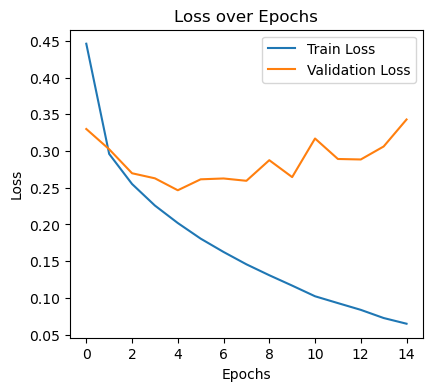

In [133]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

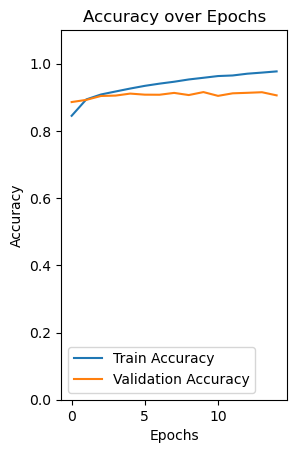

In [134]:
plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.legend()
plt.show()

In [135]:
model=create_cnn_model(**best_params)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.2, verbose=1)
loss, acc = model.evaluate(X_test, y_test_cat)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7991 - loss: 0.5634 - val_accuracy: 0.8838 - val_loss: 0.3182
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8974 - loss: 0.2855 - val_accuracy: 0.9016 - val_loss: 0.2779
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9125 - loss: 0.2359 - val_accuracy: 0.9047 - val_loss: 0.2657
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9246 - loss: 0.2044 - val_accuracy: 0.9092 - val_loss: 0.2545
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9343 - loss: 0.1758 - val_accuracy: 0.9137 - val_loss: 0.2473
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9040 - loss: 0.2709
Test Accuracy: 0.9071
Test Loss: 0.2627


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

- **My final CNN model reached about 0.91 accuracy, which is a clear improvement from the baseline model. The main reason for this boost is that the CNN can capture spatial and local features from images, something the simple dense model couldn’t do well.**

- **I experimented with several hyperparameters like the number of filters, kernel size, dropout, and L2 regularization, and gradually narrowed down to the best setup. If I had more time, I’d try running the experiments in parallel to test more hyperparameter combinations together. I’d also explore things like data augmentation or learning rate adjustments, which might push the accuracy a bit higher.**

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.